In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-6'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-6


# <u>Transformer Variants: Encoder-Only Models</u>

In the previous notebooks we examined the **full encoder–decoder Transformer architecture**, which is typically used for sequence-to-sequence tasks such as machine translation.

In many natural language processing tasks, however, we do not need to generate sequences. Instead, we want to **encode an input sentence into a representation and use it for classification or regression**. For such tasks, we can use only the **encoder part of the Transformer**. A well-known example of an encoder-only architecture is **BERT (Bidirectional Encoder Representations from Transformers)**.

The main idea behind BERT is that the model reads the entire sentence simultaneously and learns contextual representations of each token. In contrast to autoregressive models, BERT is **bidirectional**, meaning that every token can attend to both the tokens that come before it and those that come after it. The idea is similar to the BiLSTMs that we saw previously, but a difference here is that BERT is fully bidirectional in a single pass via self-attention.

In this notebook we will implement a simplified **BERT-style Transformer encoder**. It is inspired by BERT, but not an exact reproduction of the original model or its pretraining procedure. We will apply it to a sentiment classification task using the **SST-2 dataset** from the GLUE benchmark.

In [ ]:
!pip install datasets

In [ ]:
!pip install torchinfo

In [ ]:
import random
import torch as tc
import torch.nn as nn
from tqdm import tqdm
from time import perf_counter
from torchinfo import summary
from collections import Counter
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import DataLoader

device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
bar = 128*'-'

Using device: cuda


### <u>SST-2 Dataset</u>

To demonstrate how encoder-only Transformers can be used for classification tasks, we use the **SST-2 dataset (Stanford Sentiment Treebank)**. Each sample in the dataset consists of:

1) a sentence  
2) a binary sentiment label,<br> where 0 = negative sentiment, and 1 = positive sentiment.

Example:

Sentence: "contains no wit, only labored gags"  
Label: 0

Sentence: "that loves its characters and communicates something beautiful"  
Label: 1

Our goal is to train a Transformer encoder that reads a sentence and predicts whether the sentiment expressed in the sentence is **positive or negative**.

Load SST-2 dataset:

In [ ]:
dataset = load_dataset("glue", "sst2")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


Samples to see how it looks:

In [ ]:
for i in range(5):
    print(dataset["train"][i])

{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}
{'sentence': 'contains no wit , only labored gags ', 'label': 0, 'idx': 1}
{'sentence': 'that loves its characters and communicates something rather beautiful about human nature ', 'label': 1, 'idx': 2}
{'sentence': 'remains utterly satisfied to remain the same throughout ', 'label': 0, 'idx': 3}
{'sentence': 'on the worst revenge-of-the-nerds clichés the filmmakers could dredge up ', 'label': 0, 'idx': 4}


Train/Validation split:

In [ ]:
train_texts = dataset["train"]["sentence"]
train_labels = dataset["train"]["label"]

val_texts = dataset["validation"]["sentence"]
val_labels = dataset["validation"]["label"]

print(
    f"Train size: {len(train_texts)}\n"
    f"Validation size: {len(val_texts)}"
)

Train size: 67349
Validation size: 872


Dataloaders:

In [ ]:
class SST2Dataset(tc.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [ ]:
train_dataset = SST2Dataset(train_texts, train_labels)
val_dataset = SST2Dataset(val_texts, val_labels)

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

Inspect one batch:

In [ ]:
batch = next(iter(train_loader))

texts, labels = batch

print(
    f"Texts:\n{texts}\n\n"
    f"Labels:\n{labels}"
)

Texts:
('grandiloquent ', 'nicole kidman evolved from star to superstar some time over the past year , which means that birthday girl is the kind of quirkily appealing minor movie she might not make for a while . ', 'a beautiful paean to a time ', "it 's a fun adventure movie for kids ( of all ages ) that like adventure . ", 'you wish you were at home watching that movie instead of in the theater watching this one ', 'his body ', 'the most politically audacious films of recent decades ', 'for most movies , 84 minutes is short , ', 'the gross-out comedy ', 'skillful ', 'than its sunny disposition ', 'no satisfaction ', 'wholesome and subversive ', 'it never lacks in eye-popping visuals ', "this cinderella story does n't have a single surprise up its sleeve . ", 'poignancy , and intelligence ')

Labels:
tensor([1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1])


### <u>Tokenization and Vocabulary</u>

Neural networks cannot directly process text. Therefore, we must first convert sentences into **numerical representations**. This process involves three main steps:

1) **Tokenization**: The sentence is split into individual tokens (words or subwords).

2) **Vocabulary construction**: Each token is assigned a unique integer index.

3) **Encoding**: The tokenized sentence is converted into a sequence of integer IDs.

For example, the sentence:

`"hide new secretions from the parental units"`

might be tokenized as:

`["hide", "new", "secretions", "from", "the", "parental", "units"]`,

where each token is then mapped to its corresponding ID in the vocabulary, e.g.:

`[1012, 2047, 3595, 2013, 1996, 18602, 3197]`

We also introduce three special tokens:

`<pad>` : padding token  
`<unk>` : unknown token  
`<cls>` : classification token (beginning of each sentence)

Simple tokenizer:

In [ ]:
pad_token = "<pad>"
unk_token = "<unk>"
cls_token = "<cls>"

pad_id = 0
unk_id = 1
cls_id = 2

def tokenize(text):
    return text.lower().split()

example = train_texts[0]
print(
    f"Sentence: {example}\n"
    f"Tokens  : {tokenize(example)}"
)

Sentence: hide new secretions from the parental units 
Tokens  : ['hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']


Vocabulary:

In [ ]:
token_counter = Counter()

for text in train_texts:
    token_counter.update(tokenize(text))

vocab = {
    pad_token: pad_id,
    unk_token: unk_id,
    cls_token: cls_id
}

for token in token_counter:
    if token not in vocab:
        vocab[token] = len(vocab)

print(
    f"Vocabulary size: {len(vocab)}\n"
    f"First 20 tokens: {list(vocab.items())[:20]}"
)

Vocabulary size: 14819
First 20 tokens: [('<pad>', 0), ('<unk>', 1), ('<cls>', 2), ('hide', 3), ('new', 4), ('secretions', 5), ('from', 6), ('the', 7), ('parental', 8), ('units', 9), ('contains', 10), ('no', 11), ('wit', 12), (',', 13), ('only', 14), ('labored', 15), ('gags', 16), ('that', 17), ('loves', 18), ('its', 19)]


Encode sentence into token IDs:

In [ ]:
def encode(text, vocab):
    tokens = [cls_token] + tokenize(text)
    return [vocab.get(tok, unk_id) for tok in tokens]

example_ids = encode(train_texts[0], vocab)

print(
    f"Sentence : {train_texts[0]}\n"
    f"Token ids: {example_ids}"
)

Sentence : hide new secretions from the parental units 
Token ids: [2, 3, 4, 5, 6, 7, 8, 9]


Inspect Token/ID alignment:

In [ ]:
example_tokens = [cls_token] + tokenize(train_texts[0])
example_ids = encode(train_texts[0], vocab)

print(
    f"Tokens: {example_tokens}\n"
    f"IDs   : {example_ids}"
)

Tokens: ['<cls>', 'hide', 'new', 'secretions', 'from', 'the', 'parental', 'units']
IDs   : [2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
max_len = 32

### <u>Padding and Attention Masks</u>

Neural networks typically operate on batches of data, which means that all sequences in a batch must have the **same length**.

However, sentences in natural language have variable lengths. To solve this problem, we apply **padding**.

If a sentence is shorter than the maximum sequence length, we append the `<pad>` token until the desired length is reached.

Example:

Original sequence:

`[<cls>, hide, new, secretions]`

Padded sequence (max length = $8$):

`[<cls>, hide, new, secretions, <pad>, <pad>, <pad>, <pad>]`

To prevent the model from attending to these artificial tokens, we create an **attention mask**, with values $1$ = real token, and $0$ = padding token.

During attention computation, positions corresponding to padding tokens are ignored so that they do not influence the model's predictions.

In [ ]:
def pad_and_truncate(token_ids, max_len, pad_id=0):
    token_ids = token_ids[:max_len]
    attention_mask = [1] * len(token_ids)

    while len(token_ids) < max_len:
        token_ids.append(pad_id)
        attention_mask.append(0)

    return token_ids, attention_mask

example_ids = encode(train_texts[0], vocab)
padded_ids, attn_mask = pad_and_truncate(example_ids, max_len, pad_id)

print(
    f"Encoded ids     : {example_ids}\n"
    f"Padded ids      : {padded_ids}\n"
    f"Attention mask  : {attn_mask}\n"
    f"Final length    : {len(padded_ids)}"
)

Encoded ids     : [2, 3, 4, 5, 6, 7, 8, 9]
Padded ids      : [2, 3, 4, 5, 6, 7, 8, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask  : [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Final length    : 32


Update the Dataset Class:

In [ ]:
class SST2Dataset(tc.utils.data.Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        token_ids = encode(text, self.vocab)
        token_ids, attention_mask = pad_and_truncate(
            token_ids, self.max_len, pad_id
        )

        return (
            tc.tensor(token_ids, dtype=tc.long),
            tc.tensor(attention_mask, dtype=tc.long),
            tc.tensor(label, dtype=tc.long)
        )

Rebuild datasets & loaders:

In [ ]:
train_dataset = SST2Dataset(train_texts, train_labels, vocab, max_len)
val_dataset = SST2Dataset(val_texts, val_labels, vocab, max_len)

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

Inspect a preprocessed batch:

In [ ]:
input_ids, attention_masks, labels = next(iter(train_loader))

print(
    f"input_ids shape      : {input_ids.shape}\n"
    f"attention_masks shape: {attention_masks.shape}\n"
    f"labels shape         : {labels.shape}\n\n"
    f"input_ids:\n{input_ids}\n\n"
    f"attention_masks:\n{attention_masks}\n\n"
    f"labels:\n{labels}"
)

input_ids shape      : torch.Size([16, 32])
attention_masks shape: torch.Size([16, 32])
labels shape         : torch.Size([16])

input_ids:
tensor([[    2,   734,  6856,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0],
        [    2,    64,  9712,  1874,   562,    17,   996,    57,   350,   144,
            44,   744,    32,   720,     7,   396,    44,  3063,  6069,   612,
          2671,   666,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0],
        [    2,    64,  1065,  1972,   450,    68,  1271,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0],
        [    2,    86,   119,     0,     0,     0,     0,     0,     0,     0

Decode one example back:

In [ ]:
id_to_token = {idx: tok for tok, idx in vocab.items()}

sample_ids, sample_mask, sample_label = train_dataset[0]

decoded_tokens = [id_to_token[i.item()] for i in sample_ids]

print(
    f"Original sentence:\n{train_texts[0]}\n\n"
    f"Decoded tokens:\n{decoded_tokens}\n\n"
    f"Attention mask:\n{sample_mask.tolist()}\n\n"
    f"Label:\n{sample_label.item()}"
)

Original sentence:
hide new secretions from the parental units 

Decoded tokens:
['<cls>', 'hide', 'new', 'secretions', 'from', 'the', 'parental', 'units', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Label:
0


In [ ]:
lengths = attention_masks.sum(dim=1)

print(
    f"Mask lengths:\n{lengths}\n\n"
    f"Number of non-pad tokens in first sample:\n{(input_ids[0] != pad_id).sum()}"
)

Mask lengths:
tensor([ 3, 22,  7,  3,  4,  8,  8,  3, 32, 10,  8,  3, 10, 29,  2, 32])

Number of non-pad tokens in first sample:
3


Positional encoding like before:

In [ ]:
loge4 = 4 * tc.log(tc.tensor(10.0))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len):
        super().__init__()

        position = tc.arange(0, max_seq_len, dtype=tc.float).unsqueeze(1)
        div_term = tc.exp(tc.arange(0, d_model, 2).float() * -(loge4 / d_model))

        pe = tc.zeros(max_seq_len, d_model)
        pe[:, 0::2] = tc.sin(position * div_term)
        pe[:, 1::2] = tc.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### <u>Encoder-Only Transformer Architecture</u>

The model we implement in this notebook is a **BERT-like encoder-only Transformer**. The architecture consists of the following components:

1) **Token embedding layer**: Each token ID is converted into a vector of dimension `d_model` like we discussed in the previous notebooks.

2) **Positional encoding**: Since the Transformer processes tokens in parallel, positional encodings are added to the embeddings to provide information about the order of tokens as we have already seen previously.

3) **Transformer encoder**: Likewise, the encoder is composed of stacked layers containing multi-head self-attention, position-wise feed-forward networks, residual connections, layer normalization.

4) **Classification head**: After passing through the encoder, we take the representation of the `<cls>` token and pass it through a linear layer to obtain the final class scores.

In [ ]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        max_seq_len,
        num_classes,
        dropout=0.1
    ):
        super().__init__()

        assert d_model % num_heads == 0, \
            "d_model must be divisible by num_heads"

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_id
        )

        self.positional_encoding = PositionalEncoding(d_model, max_seq_len)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False
        )

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        src_key_padding_mask = (attention_mask == 0)

        x = self.encoder(
            src=x,
            src_key_padding_mask=src_key_padding_mask
        )

        cls_output = x[:, 0, :]
        logits = self.classifier(cls_output)

        return logits

Model hyperparameters:

In [ ]:
vocab_size = len(vocab)
d_model = 64
num_heads = 4
num_layers = 2
d_ff = 128
num_classes = 2
dropout = 0.1

Model definition & summary:

In [ ]:
model = TransformerEncoderClassifier(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_seq_len=max_len,
    num_classes=num_classes,
    dropout=dropout
).to(device)

dummy_input_ids = tc.randint(
    0, vocab_size, (1, max_len)
).to(device)

dummy_attention_mask = tc.ones(
    (1, max_len)
).to(device)

print(summary(
    model,
    input_data=(dummy_input_ids, dummy_attention_mask),
    depth=3,
    col_names=("input_size", "output_size", "num_params")
))

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
TransformerEncoderClassifier                  [1, 32]                   [1, 2]                    --
├─Embedding: 1-1                              [1, 32]                   [1, 32, 64]               948,416
├─PositionalEncoding: 1-2                     [1, 32, 64]               [1, 32, 64]               --
├─Dropout: 1-3                                [1, 32, 64]               [1, 32, 64]               --
├─TransformerEncoder: 1-4                     --                        [1, 32, 64]               --
│    └─ModuleList: 2-1                        --                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 32, 64]               [1, 32, 64]               33,472
│    │    └─TransformerEncoderLayer: 3-2      [1, 32, 64]               [1, 32, 64]               33,472
├─Linear: 1-5                                 [1, 64]                   [

View a batch:

In [ ]:
input_ids, attention_masks, labels = next(iter(train_loader))

input_ids = input_ids.to(device)
attention_masks = attention_masks.to(device)
labels = labels.to(device)

logits = model(input_ids, attention_masks)

print(
    f"input_ids shape : {input_ids.shape}\n"
    f"mask shape      : {attention_masks.shape}\n"
    f"logits shape    : {logits.shape}\n"
    f"labels shape    : {labels.shape}"
)

preds = logits.argmax(dim=1)

print(
    f"Logits:\n{logits}\n\n"
    f"Predictions:\n{preds}\n\n"
    f"Labels:\n{labels}"
)

input_ids shape : torch.Size([16, 32])
mask shape      : torch.Size([16, 32])
logits shape    : torch.Size([16, 2])
labels shape    : torch.Size([16])
Logits:
tensor([[ 0.5531,  0.7508],
        [-0.3699,  0.7387],
        [-0.2862,  0.2276],
        [-0.4226,  0.1101],
        [ 0.1323,  0.7024],
        [ 0.3623,  0.4062],
        [-0.0641,  0.1725],
        [ 0.3904,  0.0127],
        [ 0.3008,  0.8252],
        [ 0.2693,  0.0247],
        [-0.3031,  0.2983],
        [-0.2795,  0.5944],
        [ 0.0917,  0.8201],
        [-0.3609, -0.0178],
        [ 0.3352,  1.0547],
        [ 0.0731,  0.2223]], device='cuda:0', grad_fn=<AddmmBackward0>)

Predictions:
tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1], device='cuda:0')

Labels:
tensor([1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1], device='cuda:0')


Loss & Optimizer:

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = tc.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=0.01
)

Training:

In [ ]:
num_epochs = 5

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
progress_history = []

tic = perf_counter()

num_batches = len(train_loader)
checkpoints = [
    round(num_batches * p / 100)
    for p in range(5, 101, 5)
]

print(
    f"{'Epoch':>5} | {'Prog':>6} | "
    f"{'Train Loss':>10} | {'Train Acc':>10} | "
    f"{'Val Loss':>10} | {'Val Acc':>9} | "
    f"{'Time (min)':>10}\n"
    f"{bar}"
)

for epoch in range(num_epochs):
    model.train()

    chunk_loss_sum = 0.0
    chunk_correct = 0
    chunk_total = 0

    checkpoint_idx = 0

    for batch_idx, (input_ids, attention_masks, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        attention_masks = attention_masks.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_masks)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)

        chunk_loss_sum += loss.item() * labels.size(0)
        chunk_correct += (preds == labels).sum().item()
        chunk_total += labels.size(0)

        is_chunk_end = (
            checkpoint_idx < len(checkpoints)
            and (batch_idx + 1) >= checkpoints[checkpoint_idx]
        )

        if is_chunk_end:
            train_chunk_loss = chunk_loss_sum / chunk_total
            train_chunk_acc = 100 * chunk_correct / chunk_total

            epoch_progress_pct = 5 * (checkpoint_idx + 1)
            global_progress_pct = epoch * 100 + epoch_progress_pct

            train_loss_history.append(train_chunk_loss)
            train_acc_history.append(train_chunk_acc)
            progress_history.append(global_progress_pct)

            # Validation at this checkpoint:
            model.eval()

            val_loss_sum = 0.0
            val_correct = 0
            val_total = 0

            with tc.no_grad():
                for val_input_ids, val_attention_masks, val_labels in val_loader:
                    val_input_ids = val_input_ids.to(device)
                    val_attention_masks = val_attention_masks.to(device)
                    val_labels = val_labels.to(device)

                    val_logits = model(val_input_ids, val_attention_masks)
                    val_loss = loss_fn(val_logits, val_labels)

                    val_preds = val_logits.argmax(dim=1)

                    val_loss_sum += val_loss.item() * val_labels.size(0)
                    val_correct += (val_preds == val_labels).sum().item()
                    val_total += val_labels.size(0)

            val_chunk_loss = val_loss_sum / val_total
            val_chunk_acc = 100 * val_correct / val_total

            val_loss_history.append(val_chunk_loss)
            val_acc_history.append(val_chunk_acc)

            elapsed_min = (perf_counter() - tic) / 60

            print(
                f"{epoch+1:5d} | "
                f"{epoch_progress_pct:5.1f}% | "
                f"{train_chunk_loss:10.4f} | "
                f"{train_chunk_acc:9.2f}% | "
                f"{val_chunk_loss:10.4f} | "
                f"{val_chunk_acc:8.2f}% | "
                f"{elapsed_min:10.2f}"
            )

            model.train()

            chunk_loss_sum = 0.0
            chunk_correct = 0
            chunk_total = 0

            checkpoint_idx += 1

toc = perf_counter()

print(
    f"{bar}\n"
    f"Total training time: {(toc - tic)/60:.2f} minutes"
)

Epoch |   Prog | Train Loss |  Train Acc |   Val Loss |   Val Acc | Time (min)
--------------------------------------------------------------------------------------------------------------------------------
    1 |   5.0% |     0.6989 |     54.17% |     0.6900 |    51.26% |       0.05
    1 |  10.0% |     0.6763 |     58.00% |     0.7038 |    50.92% |       0.11
    1 |  15.0% |     0.6761 |     57.29% |     0.6643 |    59.29% |       0.18
    1 |  20.0% |     0.6670 |     59.02% |     0.6474 |    62.61% |       0.23
    1 |  25.0% |     0.6626 |     59.32% |     0.6677 |    58.03% |       0.37
    1 |  30.0% |     0.6449 |     63.15% |     0.6215 |    66.51% |       0.43
    1 |  35.0% |     0.6413 |     63.15% |     0.6194 |    67.20% |       0.48
    1 |  40.0% |     0.6269 |     63.57% |     0.6051 |    66.06% |       0.53
    1 |  45.0% |     0.6190 |     64.97% |     0.6180 |    64.11% |       0.59
    1 |  50.0% |     0.6189 |     64.90% |     0.6345 |    62.73% |       0.65
  

Plotting:

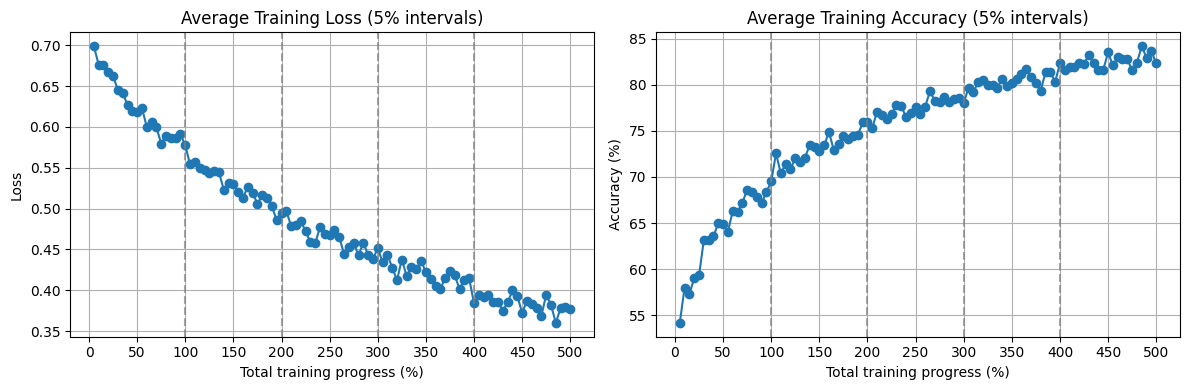

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(progress_history, train_loss_history, marker='o')
ax[0].set_xlabel("Total training progress (%)")
ax[0].set_ylabel("Loss")
ax[0].set_title("Average Training Loss (5% intervals)")
ax[0].set_xticks(range(0, num_epochs * 100 + 1, 50))
ax[0].grid(True)

ax[1].plot(progress_history, train_acc_history, marker='o')
ax[1].set_xlabel("Total training progress (%)")
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Average Training Accuracy (5% intervals)")
ax[1].set_xticks(range(0, num_epochs * 100 + 1, 50))
ax[1].grid(True)

# indicate epoch starts
for e in range(1, num_epochs):
    for a in ax:
        a.axvline(x=e * 100, linestyle='--', color='gray', alpha=0.7)

plt.tight_layout()
plt.show()
plt.close()

View some predictions:

In [ ]:
id_to_label = {
    0: "negative",
    1: "positive"
}

model.eval()

num_examples = 5
indices = random.sample(range(len(val_dataset)), num_examples)

with tc.no_grad():
    for idx in indices:
        input_ids, attention_mask, true_label = val_dataset[idx]

        text = val_texts[idx]
        true_label = true_label.item()

        input_ids = input_ids.unsqueeze(0).to(device)
        attention_mask = attention_mask.unsqueeze(0).to(device)

        logits = model(input_ids, attention_mask)
        probs = tc.softmax(logits, dim=1)

        pred_label = probs.argmax(dim=1).item()
        confidence = probs[0, pred_label].item() * 100
        is_correct = (pred_label == true_label)

        print(
            f"Sentence   : {text}\n"
            f"True label : {id_to_label[true_label]}\n"
            f"Prediction : {id_to_label[pred_label]}\n"
            f"Confidence : {confidence:.2f}%\n"
            f"Correct    : {is_correct}\n"
        )

Sentence   : good old-fashioned slash-and-hack is back ! 
True label : positive
Prediction : positive
Confidence : 98.68%
Correct    : True

Sentence   : there is a fabric of complex ideas here , and feelings that profoundly deepen them . 
True label : positive
Prediction : negative
Confidence : 63.55%
Correct    : False

Sentence   : for each chuckle there are at least 10 complete misses , many coming from the amazingly lifelike tara reid , whose acting skills are comparable to a cardboard cutout . 
True label : negative
Prediction : negative
Confidence : 61.72%
Correct    : True

Sentence   : the lion king was a roaring success when it was released eight years ago , but on imax it seems better , not just bigger . 
True label : positive
Prediction : negative
Confidence : 50.30%
Correct    : False

Sentence   : it wants to tweak them with a taste of tangy new humor . 
True label : positive
Prediction : positive
Confidence : 74.99%
Correct    : True



Custom test sentences demo:

In [ ]:
custom_examples = [
    ("This movie was absolutely fantastic", 1),
    ("I hated every minute of this film", 0),
    ("The plot was interesting but the acting was terrible", 0),
    ("A wonderful and emotional story", 1),
    ("Completely boring and predictable", 0)
]

id_to_label = {
    0: "negative",
    1: "positive"
}

model.eval()

with tc.no_grad():
    for text, true_label in custom_examples:

        token_ids = encode(text, vocab)
        token_ids, attention_mask = pad_and_truncate(
            token_ids, max_len, pad_id
        )

        input_ids = tc.tensor(token_ids).unsqueeze(0).to(device)
        attention_mask = tc.tensor(attention_mask).unsqueeze(0).to(device)

        logits = model(input_ids, attention_mask)
        probs = tc.softmax(logits, dim=1)

        pred_label = probs.argmax(dim=1).item()
        confidence = probs[0, pred_label].item() * 100

        is_correct = pred_label == true_label

        print(
            f"Sentence   : {text}\n"
            f"True label : {id_to_label[true_label]}\n"
            f"Prediction : {id_to_label[pred_label]}\n"
            f"Confidence : {confidence:.2f}%\n"
            f"Correct    : {is_correct}\n"
            f"{bar}"
        )

Sentence   : This movie was absolutely fantastic
True label : positive
Prediction : positive
Confidence : 84.26%
Correct    : True
--------------------------------------------------------------------------------------------------------------------------------
Sentence   : I hated every minute of this film
True label : negative
Prediction : positive
Confidence : 76.63%
Correct    : False
--------------------------------------------------------------------------------------------------------------------------------
Sentence   : The plot was interesting but the acting was terrible
True label : negative
Prediction : negative
Confidence : 92.14%
Correct    : True
--------------------------------------------------------------------------------------------------------------------------------
Sentence   : A wonderful and emotional story
True label : positive
Prediction : positive
Confidence : 98.71%
Correct    : True
-----------------------------------------------------------------------------

## <u>Other Transformer Variants</u>

In this notebook we focused on an **encoder-only Transformer architecture**, similar to the model used in BERT, and applied it to a sentiment classification task. Over time, several other important Transformer variants have been developed for different types of problems:

### Encoder-Only Models

One major class of Transformer models consists of **encoder-only architectures**, which use only the encoder stack to produce contextual representations of the input.

These models are designed for tasks where the goal is to **understand or classify text**, rather than generate it. They read the entire input sequence at once using **bidirectional self-attention**, allowing each token to incorporate information from both its left and right context.

The most well-known example of this family is **BERT (Bidirectional Encoder Representations from Transformers)**, along with its variants such as **RoBERTa** and **DistilBERT**. These models are commonly used for tasks like **sentiment analysis, text classification, named entity recognition, and question answering**.

### Decoder-Only Models

Another major class of Transformer models uses only the **decoder stack** of the architecture. In these models, attention is **causal**, meaning that each token can attend only to tokens that appear before it in the sequence.

This design allows the model to generate text **autoregressively**, predicting one token at a time based on the previously generated tokens.

Well-known examples are the **GPT (Generative Pre-trained Transformer) family**, including models such as GPT-1, GPT-2, GPT-3, etc. These models form the basis of many modern large language models used for tasks such as dialogue systems, code generation, assistants, etc.

### Vision Transformers (ViT)

Transformers are not limited to natural language processing. They have also been successfully applied to computer vision through the **Vision Transformer (ViT)** architecture.

Instead of processing words, an image is divided into small patches, which are treated as tokens. Each patch is embedded into a vector representation, and the sequence of patch embeddings is processed by a Transformer encoder in similar way that word embeddings are processed in other models.

Vision Transformers are used for tasks such as image classification, object detection, image segmentation, etc.

### Transformers for Long Sequences

Another important line of work focuses on making Transformers more efficient when processing **very long sequences**.

In the standard Transformer architecture, the attention mechanism scales with the **square of the sequence length**, which can become computationally expensive for long inputs. Several models modify the attention mechanism to address this limitation.

Examples include architectures such as **Longformer** and **Performer**, which introduce more efficient attention mechanisms that allow Transformer models to process much longer sequences.

## <u>Optional Assignments</u>

The following exercises are optional and intended to deepen your understanding of Transformer architectures and their applications.

### 1) Improving the Model

The model implemented in this notebook is intentionally simple so that the architecture can be clearly understood. Try to obtain better performance on the SST-2 task by modifying the model and/or its hyperparameters.

### 2) Implementing a Transformer Variant

Another useful exercise is to implement a different Transformer variant. For example, you can extend the model of this notebook to bring it closer to the original BERT, or implement another variant of your choice.

### 3) Training the Variant on a Suitable Task

After implementing the new architecture, train it on a task appropriate for that model and achieve a satisfiable performance.

## <u>References</u>

+ Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017).  
  *Attention Is All You Need.*  
  Advances in Neural Information Processing Systems (NeurIPS).  
  https://arxiv.org/abs/1706.03762

+ Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019).  
  *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.*  
  Proceedings of NAACL-HLT.  
  https://arxiv.org/abs/1810.04805

+ Radford, A., Narasimhan, K., Salimans, T., & Sutskever, I. (2018).  
  *Improving Language Understanding by Generative Pre-Training.*  
  OpenAI Technical Report.  
  https://openai.com/research/language-unsupervised

+ Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021).  
  *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.*  
  International Conference on Learning Representations (ICLR).  
  https://arxiv.org/abs/2010.11929

+ PyTorch Documentation – Transformer module:  
  https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html

+ PyTorch Documentation – TransformerEncoder:  
  https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html

+ HuggingFace Datasets – GLUE Benchmark (SST-2):  
  https://huggingface.co/datasets/glue

+ Dive into Deep Learning – Attention and Transformers:  
  https://d2l.ai/chapter_attention-mechanisms/